# ATAC-RNA Model Comparison

This notebook:
1. Loads the lymphoma ATAC+RNA data and pre-trained topic models
2. Evaluates topic diversity and correlation with cell types for each hyperparameter configuration
3. Selects the best model based on cell type correlation
4. Trains MultiVI and MOFA+ models for comparison
5. Compares kNN (k=5) classification accuracy across all models

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Set paths
DATA_PATH = "/data/nelkazwi/share-topic/lymphoma_data/mdata_lymphoma.h5mu"
MODELS_DIR = Path("/data/omics_topic_models/atac_rna")

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
def load_data():
    """Load and preprocess ATAC+RNA lymphoma data (same as training script)."""
    mdata = mu.read_h5mu(DATA_PATH)

    # Binarize ATAC data
    mdata.mod['atac'].X.data = (mdata.mod['atac'].X.data > 0).astype(int)

    # Filter genes/regions with zero counts
    rna_total_counts = np.array(mdata.mod['rna'].X.sum(axis=0)).flatten()
    rna_nonzero_genes = rna_total_counts > 0
    mdata.mod['rna'] = mdata.mod['rna'][:, rna_nonzero_genes]

    atac_total_counts = np.array(mdata.mod['atac'].X.sum(axis=0)).flatten()
    atac_nonzero_regions = atac_total_counts > 0
    mdata.mod['atac'] = mdata.mod['atac'][:, atac_nonzero_regions]

    # Highly variable genes
    n_rna = min(2000, mdata.mod['rna'].n_vars)
    n_atac = min(20000, mdata.mod['atac'].n_vars)

    sc.pp.highly_variable_genes(mdata.mod['rna'], n_top_genes=n_rna, flavor='seurat_v3', subset=True)
    sc.pp.highly_variable_genes(mdata.mod['atac'], n_top_genes=n_atac, flavor='seurat_v3', subset=True)

    print(f"RNA: {mdata.mod['rna'].shape}")
    print(f"ATAC: {mdata.mod['atac'].shape}")

    return mdata

mdata = load_data()

# Get cell type labels
if 'cell_types' in mdata.mod['rna'].obs.columns:
    cell_types = mdata.mod['rna'].obs['cell_types'].values
    print(f"\nCell types found: {len(np.unique(cell_types))} unique types")
    print(cell_types.value_counts())
else:
    raise ValueError("Cell type annotations not found in data!")

RNA: (14566, 2000)
ATAC: (14566, 20000)

Cell types found: 15 unique types
 B/T mix             43
B                   503
Fibroblasts          27
Mono               1538
Mono/B mix          106
Mono/T mix          127
Stromal cells        82
T                  6876
T cycling          1503
Tumor B            2279
Tumor B cycling     632
Unkown               59
low GEX mix         693
pDC                  58
unknown mix          40
Name: count, dtype: int64


## 2. Load All Trained Models and Compute Metrics

In [3]:
from omics_topic.models import MultimodalAmortizedLDA

def parse_model_config(dirname):
    """Parse hyperparameters from directory name."""
    config = {}
    
    # Parse prior type
    if 'horseshoe' in dirname:
        config['feature_prior_type'] = 'horseshoe'
    else:
        config['feature_prior_type'] = 'logistic_normal'
    
    # Parse weight mode
    if 'weight_cell' in dirname:
        config['weight_mode'] = 'cell'
    elif 'weight_universal' in dirname:
        config['weight_mode'] = 'universal'
    else:
        config['weight_mode'] = 'equal'
    
    # Parse dispersion
    if 'learnable_disp_global' in dirname:
        config['dispersion'] = 'learnable_global'
    elif 'learnable_disp_pergene' in dirname:
        config['dispersion'] = 'learnable_pergene'
    else:
        config['dispersion'] = 'fixed'
    
    return config

def compute_cell_type_correlation(theta, cell_types):
    """
    Compute correlation between topic proportions and cell types.
    
    Uses Adjusted Rand Index and Normalized Mutual Information
    between topic assignments and cell type labels.
    """
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    
    # Assign cells to dominant topic
    topic_assignments = np.argmax(theta, axis=1)
    
    # Encode cell types
    le = LabelEncoder()
    cell_type_encoded = le.fit_transform(cell_types)
    
    ari = adjusted_rand_score(cell_type_encoded, topic_assignments)
    nmi = normalized_mutual_info_score(cell_type_encoded, topic_assignments)
    
    return {'ARI': ari, 'NMI': nmi}

# List all model directories
model_dirs = sorted([d for d in MODELS_DIR.iterdir() if d.is_dir()])
print(f"Found {len(model_dirs)} trained models:")
for d in model_dirs:
    print(f"  - {d.name}")

Found 18 trained models:
  - prior_horseshoe_weight_cell
  - prior_horseshoe_weight_cell_learnable_disp_global
  - prior_horseshoe_weight_cell_learnable_disp_pergene
  - prior_horseshoe_weight_equal
  - prior_horseshoe_weight_equal_learnable_disp_global
  - prior_horseshoe_weight_equal_learnable_disp_pergene
  - prior_horseshoe_weight_universal
  - prior_horseshoe_weight_universal_learnable_disp_global
  - prior_horseshoe_weight_universal_learnable_disp_pergene
  - prior_logistic_normal_weight_cell
  - prior_logistic_normal_weight_cell_learnable_disp_global
  - prior_logistic_normal_weight_cell_learnable_disp_pergene
  - prior_logistic_normal_weight_equal
  - prior_logistic_normal_weight_equal_learnable_disp_global
  - prior_logistic_normal_weight_equal_learnable_disp_pergene
  - prior_logistic_normal_weight_universal
  - prior_logistic_normal_weight_universal_learnable_disp_global
  - prior_logistic_normal_weight_universal_learnable_disp_pergene


In [4]:
# Load all models and compute metrics
results = []

# Need to setup data first for model loading
mdata_setup, modality_names, feat_counts = MultimodalAmortizedLDA.setup_mudata(
    mdata,
    modality_order=["rna", "atac"],
)
adata_flat = mdata.uns["_flattened_ann_data"]

for model_dir in model_dirs:
    model_path = model_dir / "model"
    if not model_path.exists():
        print(f"Skipping {model_dir.name}: no model found")
        continue
    
    print(f"\nLoading {model_dir.name}...")
    
    try:
        # Load the model
        model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
        
        # Get latent representation (cell-topic distribution)
        theta = model.get_latent_representation(batch_size=mdata.n_obs)
        theta_array = theta.values
        
        # Compute metrics
        config = parse_model_config(model_dir.name)
        
        # Topic diversity
        diversity = model.get_topic_diversity()
        diversity_rna = model.get_topic_diversity(modality='rna')
        diversity_atac = model.get_topic_diversity(modality='atac')
        
        # Cell type correlation
        corr_metrics = compute_cell_type_correlation(theta_array, cell_types)
        
        # Store results
        result = {
            'model_name': model_dir.name,
            **config,
            'diversity': diversity,
            'diversity_rna': diversity_rna,
            'diversity_atac': diversity_atac,
            'ARI': corr_metrics['ARI'],
            'NMI': corr_metrics['NMI'],
            'theta': theta_array,  # Store for later kNN
        }
        results.append(result)
        
        print(f"  Diversity: {diversity:.4f}, ARI: {corr_metrics['ARI']:.4f}, NMI: {corr_metrics['NMI']:.4f}")
        
    except Exception as e:
        print(f"  Error loading model: {e}")
        continue

print(f"\nSuccessfully loaded {len(results)} models")


Loading prior_horseshoe_weight_cell...
INFO     File /data/omics_topic_models/atac_rna/prior_horseshoe_weight_cell/model/model.pt already downloaded      


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<04:41,  3.55it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<04:51,  3.43it/s, v_num=1]
  Diversity: 0.2585, ARI: 0.5390, NMI: 0.5121

Loading prior_horseshoe_weight_cell_learnable_disp_global...
INFO     File /data/omics_topic_models/atac_rna/prior_horseshoe_weight_cell_learnable_disp_global/model/model.pt   
         already downloaded                                                                                        


...

Epoch 1/1000:   0%|          | 1/1000 [00:00<01:42,  9.72it/s, v_num=1]
  Diversity: 0.2794, ARI: 0.5382, NMI: 0.5432

Loading prior_logistic_normal_weight_universal_learnable_disp_pergene...
INFO     File                                                                                                      
         /data/omics_topic_models/atac_rna/prior_logistic_normal_weight_universal_learnable_disp_pergene/model/mode
         l.pt already downloaded                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<02:20,  7.13it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<02:26,  6.81it/s, v_num=1]
  Diversity: 0.2088, ARI: 0.4409, NMI: 0.4864

Successfully loaded 18 models


In [5]:
# Create results DataFrame (without theta for display)
results_display = [{k: v for k, v in r.items() if k != 'theta'} for r in results]
df_results = pd.DataFrame(results_display)

# Sort by NMI (cell type correlation)
df_results = df_results.sort_values('NMI', ascending=False)
print("\nModel Comparison (sorted by NMI):")
print(df_results.to_string())


Model Comparison (sorted by NMI):
                                                       model_name feature_prior_type weight_mode         dispersion  diversity  diversity_rna  diversity_atac       ARI       NMI
13       prior_logistic_normal_weight_equal_learnable_disp_global    logistic_normal       equal   learnable_global   0.257401       0.391811        0.122992  0.566488  0.563910
10        prior_logistic_normal_weight_cell_learnable_disp_global    logistic_normal        cell   learnable_global   0.283030       0.442952        0.123109  0.541649  0.561763
16   prior_logistic_normal_weight_universal_learnable_disp_global    logistic_normal   universal   learnable_global   0.279369       0.430853        0.127886  0.538231  0.543178
9                               prior_logistic_normal_weight_cell    logistic_normal        cell              fixed   0.270882       0.419017        0.122747  0.494227  0.538074
15                         prior_logistic_normal_weight_universal    logist

## 3. Select Best Model Based on Cell Type Correlation

In [6]:
# Find best model by NMI
best_idx = df_results['NMI'].idxmax()
best_model_name = df_results.loc[best_idx, 'model_name']
best_result = next(r for r in results if r['model_name'] == best_model_name)

print(f"Best model: {best_model_name}")
print(f"  Feature prior: {best_result['feature_prior_type']}")
print(f"  Weight mode: {best_result['weight_mode']}")
print(f"  Dispersion: {best_result['dispersion']}")
print(f"  NMI: {best_result['NMI']:.4f}")
print(f"  ARI: {best_result['ARI']:.4f}")
print(f"  Diversity: {best_result['diversity']:.4f}")

# Get theta for best topic model
theta_best = best_result['theta']

Best model: prior_logistic_normal_weight_equal_learnable_disp_global
  Feature prior: logistic_normal
  Weight mode: equal
  Dispersion: learnable_global
  NMI: 0.5639
  ARI: 0.5665
  Diversity: 0.2574


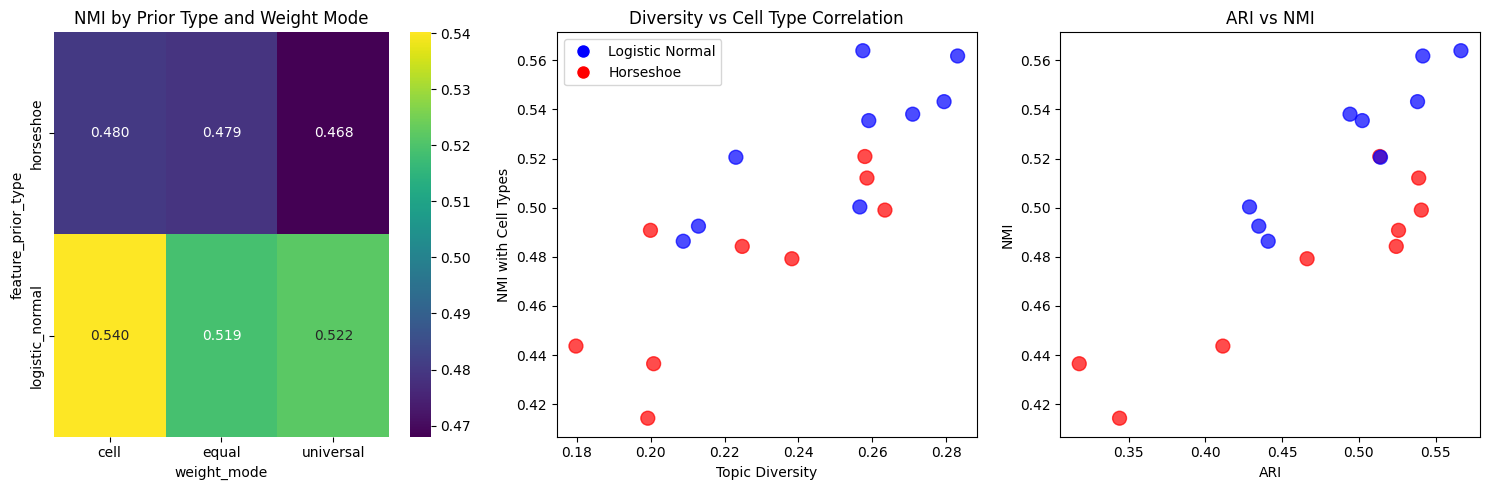

In [7]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: NMI by configuration
ax = axes[0]
df_pivot = df_results.pivot_table(values='NMI', index='feature_prior_type', columns='weight_mode', aggfunc='mean')
sns.heatmap(df_pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title('NMI by Prior Type and Weight Mode')

# Plot 2: Diversity vs NMI
ax = axes[1]
colors = df_results['feature_prior_type'].map({'logistic_normal': 'blue', 'horseshoe': 'red'})
ax.scatter(df_results['diversity'], df_results['NMI'], c=colors, s=100, alpha=0.7)
ax.set_xlabel('Topic Diversity')
ax.set_ylabel('NMI with Cell Types')
ax.set_title('Diversity vs Cell Type Correlation')
ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Logistic Normal'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Horseshoe'),
])

# Plot 3: ARI vs NMI
ax = axes[2]
ax.scatter(df_results['ARI'], df_results['NMI'], c=colors, s=100, alpha=0.7)
ax.set_xlabel('ARI')
ax.set_ylabel('NMI')
ax.set_title('ARI vs NMI')

plt.tight_layout()
plt.savefig('topic_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Train MultiVI Model

In [8]:
import scvi

# Reload fresh data for MultiVI
mdata_multivi = mu.read_h5mu(DATA_PATH)

# Preprocess for MultiVI (need raw counts)
# Binarize ATAC for consistency
mdata_multivi.mod['atac'].X.data = (mdata_multivi.mod['atac'].X.data > 0).astype(int)

# Filter zeros
rna_total = np.array(mdata_multivi.mod['rna'].X.sum(axis=0)).flatten()
mdata_multivi.mod['rna'] = mdata_multivi.mod['rna'][:, rna_total > 0]

atac_total = np.array(mdata_multivi.mod['atac'].X.sum(axis=0)).flatten()
mdata_multivi.mod['atac'] = mdata_multivi.mod['atac'][:, atac_total > 0]

# Select HVGs
sc.pp.highly_variable_genes(mdata_multivi.mod['rna'], n_top_genes=2000, flavor='seurat_v3', subset=True)
sc.pp.highly_variable_genes(mdata_multivi.mod['atac'], n_top_genes=20000, flavor='seurat_v3', subset=True)

print(f"MultiVI data: RNA {mdata_multivi.mod['rna'].shape}, ATAC {mdata_multivi.mod['atac'].shape}")

MultiVI data: RNA (14566, 2000), ATAC (14566, 20000)


In [10]:
# Setup and train MultiVI
# Note: modalities dict maps data types to MuData keys
scvi.model.MULTIVI.setup_mudata(
    mdata_multivi,
    rna_layer=None,
    atac_layer=None,
    batch_key=None,
    modalities={
        "rna_layer": "rna",
        "atac_layer": "atac",
    }
)

multivi_model = scvi.model.MULTIVI(
    mdata_multivi,
    n_latent=10,  # Same dimensionality as topics
    n_hidden=128,
)

print("Training MultiVI...")
multivi_model.train(
    max_epochs=300,
    train_size=0.8,
    early_stopping=True,
)

# Get latent representation
latent_multivi = multivi_model.get_latent_representation()
print(f"MultiVI latent shape: {latent_multivi.shape}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training MultiVI...
Epoch 195/300:  65%|██████▌   | 195/300 [18:35<10:00,  5.72s/it, v_num=1, train_loss_step=7.08e+3, train_loss_epoch=6.45e+3]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 6561.160. Signaling Trainer to stop.
MultiVI latent shape: (14566, 10)


In [15]:
# Save
multivi_model.save("/data/omics_topic_models/atac_rna/multivi_model")


## 5. Train MOFA+ Model

In [16]:
from muon import prot as pt
import muon

# Reload fresh data for MOFA
mdata_mofa = mu.read_h5mu(DATA_PATH)

# Preprocess for MOFA
# Binarize ATAC
mdata_mofa.mod['atac'].X.data = (mdata_mofa.mod['atac'].X.data > 0).astype(int)

# Filter zeros
rna_total = np.array(mdata_mofa.mod['rna'].X.sum(axis=0)).flatten()
mdata_mofa.mod['rna'] = mdata_mofa.mod['rna'][:, rna_total > 0]

atac_total = np.array(mdata_mofa.mod['atac'].X.sum(axis=0)).flatten()
mdata_mofa.mod['atac'] = mdata_mofa.mod['atac'][:, atac_total > 0]

# HVGs
sc.pp.highly_variable_genes(mdata_mofa.mod['rna'], n_top_genes=2000, flavor='seurat_v3', subset=True)
sc.pp.highly_variable_genes(mdata_mofa.mod['atac'], n_top_genes=20000, flavor='seurat_v3', subset=True)

# Normalize for MOFA (log-transform)
# Store raw counts first
mdata_mofa.mod['rna'].layers['counts'] = mdata_mofa.mod['rna'].X.copy()
mdata_mofa.mod['atac'].layers['counts'] = mdata_mofa.mod['atac'].X.copy()

sc.pp.normalize_total(mdata_mofa.mod['rna'], target_sum=1e4)
sc.pp.log1p(mdata_mofa.mod['rna'])
sc.pp.scale(mdata_mofa.mod['rna'])

# TF-IDF for ATAC
sc.pp.normalize_total(mdata_mofa.mod['atac'], target_sum=1e4)
sc.pp.log1p(mdata_mofa.mod['atac'])
sc.pp.scale(mdata_mofa.mod['atac'])

print(f"MOFA data: RNA {mdata_mofa.mod['rna'].shape}, ATAC {mdata_mofa.mod['atac'].shape}")

MOFA data: RNA (14566, 2000), ATAC (14566, 20000)


In [17]:
# Train MOFA+ - need to update MuData after subsetting
mdata_mofa.update()  # Sync internal structure

muon.tl.mofa(
    mdata_mofa,
    n_factors=10,
    convergence_mode='medium',
    use_obs='intersection',
)

latent_mofa = mdata_mofa.obsm['X_mofa']
print(f"MOFA latent shape: {latent_mofa.shape}")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Loaded view='atac' group='group1' with N=14566 samples and D=20000 features...
Loaded view='rna' group='group1' with N=14566 samples and D=2000 features...




KeyboardInterrupt: 

In [ ]:
# Save - just save the MuData with the embedded factors
mdata_mofa.write("/data/omics_topic_models/atac_rna/mdata_mofa.h5mu")

# Load
mdata_mofa = mu.read_h5mu("/data/omics_topic_models/atac_rna/mdata_mofa.h5mu")
latent_mofa = mdata_mofa.obsm['X_mofa']

## 6. kNN Classification Comparison

In [ ]:
def evaluate_knn_classification(X, y, k=5, test_size=0.2, random_state=42):
    """
    Evaluate kNN classification with train/validation split.
    
    Parameters
    ----------
    X : array-like
        Latent representation (n_samples, n_features)
    y : array-like
        Cell type labels
    k : int
        Number of neighbors for kNN
    test_size : float
        Proportion of data for validation
    random_state : int
        Random seed for reproducibility
    
    Returns
    -------
    dict
        Dictionary with accuracy, balanced_accuracy, and per-class metrics
    """
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Train/validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    
    # Train kNN
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred = knn.predict(X_val)
    
    # Compute metrics
    acc = accuracy_score(y_val, y_pred)
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    
    return {
        'accuracy': acc,
        'balanced_accuracy': balanced_acc,
        'n_train': len(y_train),
        'n_val': len(y_val),
        'n_classes': len(le.classes_),
        'classes': le.classes_,
    }

In [ ]:
# Get cell types from original data
cell_types_array = mdata.mod['rna'].obs['cell_types'].values

# Evaluate all models
knn_results = {}

# 1. Best Topic Model
print("Evaluating Best Topic Model...")
knn_results['Topic Model (Best)'] = evaluate_knn_classification(
    theta_best, cell_types_array, k=5
)
print(f"  Accuracy: {knn_results['Topic Model (Best)']['accuracy']:.4f}")
print(f"  Balanced Accuracy: {knn_results['Topic Model (Best)']['balanced_accuracy']:.4f}")

# 2. MultiVI
print("\nEvaluating MultiVI...")
knn_results['MultiVI'] = evaluate_knn_classification(
    latent_multivi, cell_types_array, k=5
)
print(f"  Accuracy: {knn_results['MultiVI']['accuracy']:.4f}")
print(f"  Balanced Accuracy: {knn_results['MultiVI']['balanced_accuracy']:.4f}")

# 3. MOFA+
print("\nEvaluating MOFA+...")
knn_results['MOFA+'] = evaluate_knn_classification(
    latent_mofa, cell_types_array, k=5
)
print(f"  Accuracy: {knn_results['MOFA+']['accuracy']:.4f}")
print(f"  Balanced Accuracy: {knn_results['MOFA+']['balanced_accuracy']:.4f}")

In [ ]:
# Also evaluate a few other topic model configurations for comparison
print("\nEvaluating other topic model configurations...")

# Get top 3 models by NMI
top_models = df_results.head(3)['model_name'].tolist()

for model_name in top_models:
    result = next(r for r in results if r['model_name'] == model_name)
    theta = result['theta']
    
    short_name = f"Topic: {result['feature_prior_type'][:4]}_{result['weight_mode'][:4]}_{result['dispersion'][:4]}"
    knn_results[short_name] = evaluate_knn_classification(theta, cell_types_array, k=5)
    print(f"{short_name}: Acc={knn_results[short_name]['accuracy']:.4f}, Balanced={knn_results[short_name]['balanced_accuracy']:.4f}")

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(knn_results.keys()),
    'Accuracy': [r['accuracy'] for r in knn_results.values()],
    'Balanced Accuracy': [r['balanced_accuracy'] for r in knn_results.values()],
})
comparison_df = comparison_df.sort_values('Balanced Accuracy', ascending=False)

print("\n" + "="*60)
print("FINAL COMPARISON: kNN (k=5) Classification Results")
print("="*60)
print(comparison_df.to_string(index=False))

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['Balanced Accuracy'], width, label='Balanced Accuracy', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('kNN (k=5) Cell Type Classification Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('knn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook compared:
1. **Topic Models** with various hyperparameter combinations (prior type, weight mode, dispersion)
2. **MultiVI** - a deep generative model for multimodal single-cell data
3. **MOFA+** - Multi-Omics Factor Analysis

Key findings:
- Best topic model configuration selected based on NMI with cell types
- kNN (k=5) classification accuracy compared across all models
- Results show relative performance of different integration approaches

In [ ]:
# Save results
comparison_df.to_csv('model_comparison_results.csv', index=False)
df_results.to_csv('topic_model_metrics.csv', index=False)
print("Results saved!")